In [199]:
import logging
import os
import pickle
import sys
import time
import traceback
import warnings
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from encodings import cp037
from scipy.optimize import curve_fit


logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

# ===========================
# Configuration and Setup
# ===========================
from config import db_connection, sys_path, xu_output_dir, pickle_file


os.environ['TANGOS_DB_CONNECTION'] = '/home/bk639/data_base/CDM_all_shapes.db'
os.environ['TANGOS_PROPERTY_MODULES'] = 'mytangosproperty'
sys.path.append(sys_path)

import tangos
import mytangosproperty
from MCMC_sims import get_keys


In [210]:
import pandas
filepath = 'results/summary/all_individual_results.pkl'
with open(filepath,'rb') as f:
    individual_results = pickle.load(f)

In [214]:
individual_results[('cptmarvel.cosmo25cmb.4096g5HbwK1BH', '1')]

{'samples': array([[0.85839232, 0.25196743, 0.00269062, 0.02799506],
        [0.85866987, 0.24910586, 0.00305593, 0.02626982],
        [0.85584092, 0.2509716 , 0.00715758, 0.02898314],
        ...,
        [0.85658032, 0.2509485 , 0.00493595, 0.02641642],
        [0.85738276, 0.2524524 , 0.00649027, 0.02853128],
        [0.85910762, 0.24950614, 0.00353441, 0.0279565 ]],
       shape=(172800, 4)),
 'max_prob_params': array([0.85859495, 0.24997669, 0.003505  , 0.02733716]),
 'q_obs': array([0.42264611, 0.87899884, 0.27388023, ..., 0.3268277 , 0.51942448,
        0.2366186 ], shape=(20000,)),
 'sampler': <emcee.ensemble.EnsembleSampler at 0x7fa8de7e1be0>}

In [200]:
from MCMC_sims import get_keys, smooth_shape

with open(pickle_file, 'rb') as f:
    ellipse_dict = pickle.load(f)

In [226]:
for key in ellipse_dict.keys():
    print(key)

r431.romulus25.3072g1HsbBH
cptmarvel.cosmo25cmb.4096g5HbwK1BH
elektra.cosmo25cmb.4096g5HbwK1BH
h148.cosmo50PLK.3072g3HbwK1BH
h229.cosmo50PLK.3072gst5HbwK1BH
h242.cosmo50PLK.3072gst5HbwK1BH
h329.cosmo50PLK.3072gst5HbwK1BH
r1023.romulus25.3072g1HsbBH
r442.romulus25.3072g1HsbBH
r468.romulus25.3072g1HsbBH
r488.romulus25.3072g1HsbBH
r489.romulus25.3072g1HsbBH
r492.romulus25.3072g1HsbBH
r502.romulus25.3072g1HsbBH
r515.romulus25.3072g1HsbBH
r523.romulus25.3072g1HsbBH
r544.romulus25.3072g1HsbBH
r552.romulus25.3072g1HsbBH
r555.romulus25.3072g1HsbBH
r556.romulus25.3072g1HsbBH
r563.romulus25.3072g1HsbBH
r568.romulus25.3072g1HsbBH
r569.romulus25.3072g1HsbBH
r571.romulus25.3072g1HsbBH
r597.romulus25.3072g1HsbBH
r613.romulus25.3072g1HsbBH
r614.romulus25.3072g1HsbBH
r615.romulus25.3072g1HsbBH
r618.romulus25.3072g1HsbBH
r634.romulus25.3072g1HsbBH
r642.romulus25.3072g1HsbBH
r656.romulus25.3072g1HsbBH
r707.romulus25.3072g1HsbBH
r716.romulus25.3072g1HsbBH
r718.romulus25.3072g1HsbBH
r719.romulus25.3072g1H

In [227]:

# a_list = []
# b_list = []
# c_list = []

ba_true,ba_inf = [],[]
ca_true,ca_inf = [],[]


records = []
for sim in ellipse_dict:
    halo_refs = list(ellipse_dict[sim].keys())
    #get feedback type if possible

    # --- Filter: Massive Merians (r* sims) — keep only most massive halo ---

    if sim.startswith('r') and not sim.startswith('rogue'):
        max_halo_ref, max_stars = None, 0
        for halo_ref in halo_refs:
            try:
                n_stars = tangos.get_halo(halo_ref)['n_star'][0]

                if n_stars > max_stars:
                    max_stars, max_halo_ref = n_stars, halo_ref
            except Exception:
                print(f'error in {halo_ref}')
                continue
        halo_refs = [max_halo_ref] if max_halo_ref else []
        #print(f'Keeping only most massive halo from sim {sim}')

    # --- Filter: h* sims — skip halo 0 ---
    elif sim.startswith('h'):
        halo_refs = [hr for hr in halo_refs
                     if tangos.get_halo(hr).basename.split('_')[1] != '0']
        #print(f'Removing halo 0 from sim {sim}')

    for halo_ref in halo_refs:
        halo  = tangos.get_halo(halo_ref)
        m_star = halo['M_star']

        if np.log10(m_star) < 8:
            continue
        # print(np.log10(m_star))
        hid   = halo.basename.split('_')[1]
        try:
            a = halo['a_s']
            b = halo['b_s']
            c = halo['c_s']

            rbins = halo['rbins_s']
        except Exception:
            print(f'no shape found for {sim} {hid}')
            continue
        Reff = get_keys(sim, hid, (0.0, 0.0), 'Reff')

        rbins_f, a_f, b_f, c_f, a_s_func, b_s_func, c_s_func = smooth_shape(rbins, a, b, c, k=3)
        #get a,b,c at 2*reff
        a_s = a_s_func(2*Reff)
        b_s = b_s_func(2*Reff)
        c_s = c_s_func(2*Reff)

        triaxiality = (a_s**2-b_s**2)/(a_s**2-c_s**2)
        #print(triaxiality)
        # if triaxiality > 0.33:
        #     continue
        # a_list.append(a_s)
        # b_list.append(b_s)
        # c_list.append(c_s)
        try:
            ba = b_s/a_s
            ca = c_s/a_s

            key = (f'{sim}',f'{hid}')
            max_prob_params = individual_results[key]['max_prob_params']
        except Exception:
            print(f'missing values for {key}')
            continue

        ba_true.append(ba)
        ca_true.append(ca)
        ba_inf.append(max_prob_params[0])
        ca_inf.append(max_prob_params[1])
        print(f'values added for {key}')



# A = np.array(a_list)
# B = np.array(b_list)
# C = np.array(c_list)

shape_df = pd.DataFrame(records)


values added for ('r431.romulus25.3072g1HsbBH', '1')
values added for ('elektra.cosmo25cmb.4096g5HbwK1BH', '1')
values added for ('h229.cosmo50PLK.3072gst5HbwK1BH', '2')
values added for ('h229.cosmo50PLK.3072gst5HbwK1BH', '5')
values added for ('h242.cosmo50PLK.3072gst5HbwK1BH', '8')
values added for ('h242.cosmo50PLK.3072gst5HbwK1BH', '10')
values added for ('h242.cosmo50PLK.3072gst5HbwK1BH', '11')
values added for ('r442.romulus25.3072g1HsbBH', '1')
values added for ('r468.romulus25.3072g1HsbBH', '1')
values added for ('r488.romulus25.3072g1HsbBH', '1')
values added for ('r489.romulus25.3072g1HsbBH', '1')
values added for ('r492.romulus25.3072g1HsbBH', '1')
values added for ('r502.romulus25.3072g1HsbBH', '1')
values added for ('r515.romulus25.3072g1HsbBH', '1')
values added for ('r523.romulus25.3072g1HsbBH', '1')
values added for ('r544.romulus25.3072g1HsbBH', '1')
values added for ('r552.romulus25.3072g1HsbBH', '1')
values added for ('r555.romulus25.3072g1HsbBH', '1')
values added 

In [228]:
print(len(A))

43


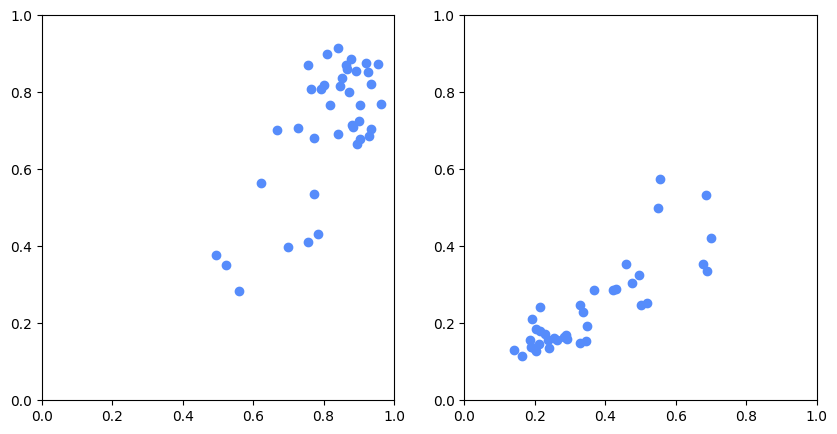

In [222]:
fig,ax = plt.subplots(1,2,figsize = (10,5))
ax[0].scatter(ba_true,ba_inf)
ax[1].scatter(ca_true,ca_inf)
for a in ax:
    a.set_xlim(0,1)
    a.set_ylim(0,1)

In [223]:
print(len(ba_true))

39


In [ ]:
from fast_likelihood import _moments, _draw

In [ ]:
keep = np.ones((len(A)))
moments,_ = _moments(A,B/A,C/A,keep,min_keep=1)

In [ ]:
moments

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from fast_likelihood import get_crn, solve_latent_fast, _draw   # your functions



def model_abc(theta, n=200_000, seed=0):
    crn = get_crn(n, seed)
    latent = solve_latent_fast(theta, crn)
    print(latent)
    if latent is None:
        raise ValueError("solve_latent_fast failed for this theta")

    crn= get_crn(43, seed)
    a, b, c, keep = _draw(latent, crn)
    idx = np.flatnonzero(keep)
    return np.column_stack([a[idx], b[idx], c[idx]])


def fit7(a, b, c):
    """Full 7-parameter summary, via your own _moments."""
    m, _ = _moments(a, b, c, np.ones(a.size, bool), min_keep=0)
    return m   # [mu_a, mu_b, mu_c, sd_a, sd_b, sd_c, rho_ac]


def ellipse_bc(p, nsig=1.0, npts=300):
    """Axis-aligned 1-sigma ellipse: rho_bc == 0 by construction."""
    _, mb, mc, _, sdb, sdc, _ = p
    t = np.linspace(0, 2 * np.pi, npts)
    return np.column_stack([mb + nsig * sdb * np.cos(t),
                            mc + nsig * sdc * np.sin(t)])


def compare(theta, A, B_over_A, C_over_A, n=200_000, seed=0, nsig=1.0):
    a_d = np.asarray(A, float).ravel()
    b_d = np.asarray(B_over_A, float).ravel()
    c_d = np.asarray(C_over_A, float).ravel()

    mod = model_abc(theta, n, seed)
    p_d = fit7(a_d, b_d, c_d)
    p_m = fit7(mod[:, 0], mod[:, 1], mod[:, 2])
    mod = model_abc(p_d, n, seed)



    fig, ax = plt.subplots(figsize=(5.5, 5.5),dpi = 300)
    ax.scatter(b_d, c_d, s=8, alpha=1, color="k", lw=0, label="data")
    ax.scatter(mod[:, 1], mod[:, 2], s=8, alpha=1, color="C0",
               lw=0, label="data - fit example")

    for p, col, lab in ((p_d, "k", "data 1σ"), (p_m, "C3", "model 1σ")):
        e = ellipse_bc(p, nsig)
        ax.plot(e[:, 0], e[:, 1], color=col, lw=2, label=lab)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_xlabel("B/A"); ax.set_ylabel("C/A")
    ax.legend(fontsize=8, frameon=False)
    fig.tight_layout()
    return fig, p_d, p_m


params = [ 2.83067323,  0.78868578,  0.25104707,  1.3778530,  0.12260548,  0.08450255,
 -0.70459993]

fig, p_data, p_model = compare(params, A/2, B/A, C/A)
print("data :", p_data)
print("model:", p_model)



NameError: name 'A' is not defined

In [ ]:
from shape_inference import project_to_attainable
from shape_inference import attainable
params = [ 6. ,   0.15,   0.1 , 2. ,   0.08 , 0.08, -0.5 ]

import numpy as np
from fast_likelihood import solve_latent_fast, get_crn, _draw
crn = get_crn(2000)

latent = solve_latent_fast(params,crn,max_iter=50)

d = _draw(latent, crn)
a, b, c, keep = d
idx = np.flatnonzero(keep)
A = a[idx]
B = b[idx]
C = c[idx]


In [ ]:
from shape_inference import cov_fit
print(cov_fit(A,B,C))

In [4]:
from shape_inference import projected_axis_ratio, projected_semi_axes, random_viewing_angles, generate_ellipsoid_distribution
import numpy as np
B,C,A,info = generate_ellipsoid_distribution([0.8,0.35,0.05,0.1],100)

In [5]:
q_2=[]
for i in range(100):
    phi,theta = random_viewing_angles(100)
    alpha,beta = projected_semi_axes(phi,theta,B,C)
    q_2.extend(beta / alpha)


(0.0, 1.0)

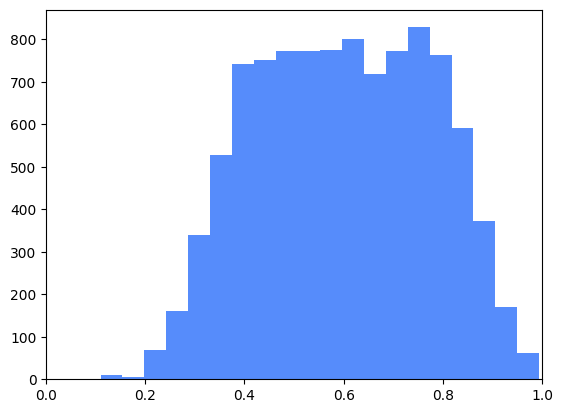

In [6]:
plt.hist(q_2,bins=20)
plt.xlim(0,1)


In [7]:
print(np.mean(B),np.mean(C),np.std(B),np.std(C))

0.7980148597365512 0.34656184645948734 0.05173073623440786 0.08859617053852098


(0.0, 1.0)

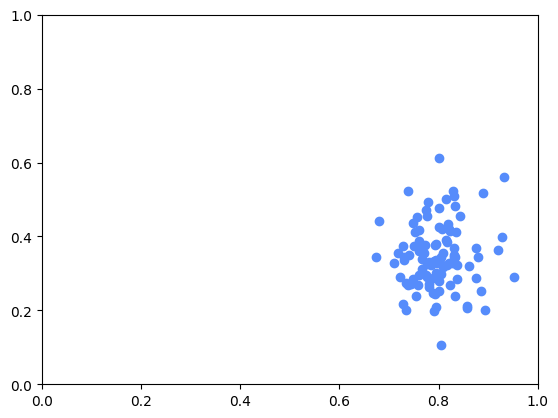

In [8]:
plt.scatter(B,C)
plt.xlim(0,1)
plt.ylim(0,1)

In [9]:
import pickle
file = 'caches/isophote_cache_cptmarvel.cosmo25cmb.4096g5HbwK1BH_n100/VBandIsophoteAnalysis_halo1.pkl'
with open(file,'rb') as f:
    data = pickle.load(f)

In [10]:
import pickle
file = 'caches/i.isophote_cache_cptmarvel.cosmo25cmb.4096g5HbwK1BH_n100/iBandIsophoteAnalysis_halo1.pkl'
with open(file,'rb') as f:
    datai = pickle.load(f)

In [ ]:
data.keys()

In [ ]:
data['0047_t+1.570796_p+2.217595']

In [ ]:
for iso in datai['0047_t+1.570796_p+2.217595']:
    print(f'r {iso[0]:.2f},e = {iso[1]:.2f}')

In [ ]:
for iso in data['0047_t+1.570796_p+2.217595']:
    print(f'r {iso[0]:.2f},e = {iso[1]:.2f}')

In [ ]:
file = 'angle_test_tangos/ellipse_data_n_100.pickle'
with open(file,'rb') as f:
    ellipse_dict = pickle.load(f)

In [ ]:
ellipse_dict

In [316]:
def generate_ellipsoids(params,n):
    mu_b,mu_c,sigma_b,sigma_c = params
    rng = np.random.default_rng()
    b = rng.normal(loc=mu_b,scale=sigma_b,size=n)
    c = rng.normal(loc=mu_c,scale=sigma_c,size=n)
    #count number of valid ellipses
    info = {}
    valid = (0 < c) & (c < b) & (b < 1)
    acc = np.sum(valid)/n

    info['acc']=acc
    if acc > 0.7:
        info['ok']=True
    else:
        info['ok']=False
    return b[valid],c[valid],info

In [11]:
params = [0.973,0.2,0.114,0.062]
#params = [0.899,0.345,0.085,0.189]
from scipy.special import ndtr, ndtri
from scipy.stats import kstest
rng = np.random.default_rng()
b,c,a = _ellipsoid_truncnorm(params,2000)
#b,c = generate_ellipsoid_distribution(params, 2000)
#b,c,info = generate_ellipsoids(params,2000)


NameError: name '_ellipsoid_truncnorm' is not defined

In [318]:
np.mean(b),np.mean(c), np.std(b),np.std(c)

(np.float64(0.9008454767183639),
 np.float64(0.20164676001047288),
 np.float64(0.07363961079122901),
 np.float64(0.058323842052955724))

In [313]:
info

{'acc': np.float64(0.584), 'ok': False}

In [ ]:
params_CDM = [0.76,0.5,0.139,0.153]
params_SIDM = [0.76,0.6,0.139,0.153]
x = [50,100,200]
q_CDM = []
q_SIDM = []
for i in range(len(x)):
    fig,ax = plt.subplots(nrows=2, figsize = (5,10))
    n = int(x[i])
    phi,theta = random_viewing_angles(n)
    B,C,_ = _ellipsoid_truncnorm(params_CDM,n,rng)
    ax[0].scatter(B,C,color='blue',s=1,alpha=1)
    alpha,beta = projected_semi_axes(phi,theta,B,C)
    q = beta/alpha
    q_CDM.append(q)
    ax[1].hist(q,color = 'blue',histtype='step')
    B,C,_ = _ellipsoid_truncnorm(params_SIDM,n,rng)
    ax[0].scatter(B,C,color='red',s=1,alpha=1)
    alpha,beta = projected_semi_axes(phi,theta,B,C)
    q = beta/alpha
    q_SIDM.append(q)
    ax[1].hist(q,color='red',histtype='step')

    ax[0].set_xlim(0,1)
    ax[0].set_ylim(0,1)
    ax[1].set_xlim(0,1)

for i in range(len(x)):
    print(kstest(q_CDM[i],q_SIDM[i]))


In [ ]:
params = [0.899,0.345,0.085,0.189]

b,c,info = generate_ellipsoids(params,n)
print(np.mean(b),np.mean(c), np.std(b),np.std(c),info)
fig = plt.figure(figsize=(7,7))
plt.scatter(b,c)
#
# plt.xlim(0,1)
# plt.ylim(0,1)
plt.plot([0,1],[0,1])

In [12]:
from shape_inference import project_ellipticity_xu, projected_semi_axes, _ellipsoid_truncnorm,random_viewing_angles


params1 = [0.906,0.349,0.074,0.171]
params2 = [0.787,0.435,0.126,0.177]
B1,C1,_ = _ellipsoid_truncnorm(params1,100)
B2,C2,_ = _ellipsoid_truncnorm(params2,100)
q_1,q_2=[],[]
for i in range(len(B1)):
    phi,theta = random_viewing_angles(100)
    alpha,beta = projected_semi_axes(phi,theta,B1[i],C1[i])
    q_1.extend(beta/alpha)
    alpha,beta = projected_semi_axes(phi,theta,B2[i],C2[i])
    q_2.extend(beta/alpha)





(0.0, 1.0)

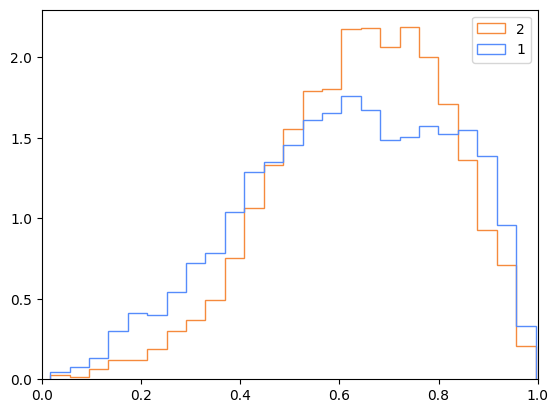

In [52]:
Q_BINS = np.arange(0, 1.0000001, 0.04)

In [15]:
Q_BINS

array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ,
       0.44, 0.48, 0.52, 0.56, 0.6 , 0.64, 0.68, 0.72, 0.76, 0.8 , 0.84,
       0.88, 0.92, 0.96, 1.  ])

In [ ]:
from galaxy_ellipse_collection import SphereInterpolator
from shape_inference import random_viewing_angles

data=ellipse_dict['r431.romulus25.3072g1HsbBH']['r431.romulus25.3072g1HsbBH/%/halo_1']
e_interpolator = SphereInterpolator(data)


In [ ]:
1 - e_interpolator(0/16*np.pi,0)[0]

In [16]:
from shape_inference import valid_theta, log_likelihood


In [53]:
n_obs, _ = np.histogram(q_obs, bins=Q_BINS)
n_model, _ = np.histogram(q_2, bins=Q_BINS)
total_model =n_model.sum()

In [218]:
from shape_inference import _binned_poisson_loglike

print(_binned_poisson_loglike(n_obs,n_model))

-486.25931017499516


In [9]:
from scipy.special import gammaln
print(gammaln(0+1))

0.0


In [56]:
q_1 = np.array(q_1)


In [60]:
n_obs,n_model

(array([  0,  23,  42,  93, 158, 160, 195, 267, 321, 370, 519, 529, 571,
        644, 650, 706, 666, 600, 600, 630, 603, 625, 547, 364, 108]),
 array([  3,   9,  19,  40,  58,  61,  93, 149, 192, 268, 394, 523, 617,
        684, 723, 871, 882, 819, 868, 807, 680, 538, 362, 265,  75]))

In [193]:
import numpy as np
from shape_inference import project_ellipticity_xu, projected_semi_axes, _ellipsoid_truncnorm,random_viewing_angles
from shape_inference import log_likelihood

params1 = [0.974,0.208,0.122,0.068]
params2 = [0.811,0.346,0.114,0.161]
B1,C1,_ = _ellipsoid_truncnorm(params1,100)
B2,C2,_ = _ellipsoid_truncnorm(params2,100)
q_1,q_2=[],[]
for i in range(len(B1)):
    phi,theta = random_viewing_angles(100)
    alpha,beta = projected_semi_axes(phi,theta,B1[i],C1[i])
    q_1.extend(beta/alpha)
    alpha,beta = projected_semi_axes(phi,theta,B2[i],C2[i])
    q_2.extend(beta/alpha)

q_1 = np.array(q_1)
q_2 = np.array(q_2)
q_obs = q_2[q_2 > 0.16]

(0.0, 1.0)

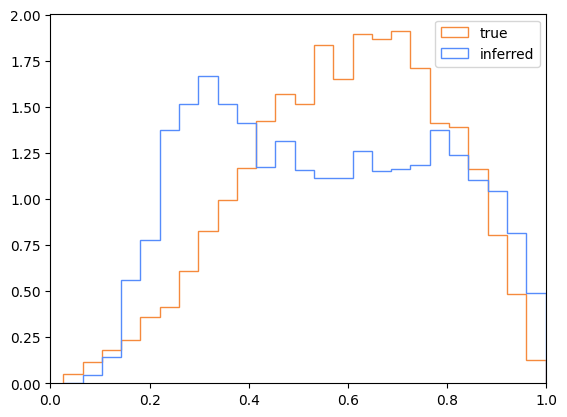

In [194]:
plt.hist([q_1,q_2],histtype='step',label=['inferred','true'],bins = 25,density=True)
plt.legend()
plt.xlim(0,1)

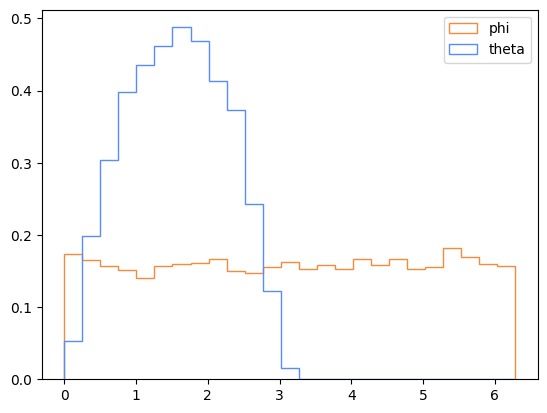

In [186]:
phi,theta = random_viewing_angles(10000)
plt.hist([theta,phi],histtype='step',label=['theta','phi'],bins = 25,density=True)
plt.legend()

In [49]:

params = [0.8,0.7,0.1,.1]

mu_B, mu_C, sigma_B, sigma_C = params
if not (0 < mu_C < mu_B <= 1):
    print(mu_B,mu_C,sigma_B,sigma_C)
ll = log_likelihood(params,q_obs)
print(ll)

nan


In [77]:
params1

[0.906, 0.349, 0.074, 0.171]

In [65]:
ni = 10
mi = 0.001
ni*np.log(mi)-mi - gammaln(ni+1)

np.float64(-84.1829653628969)

In [147]:
min_q = np.min(q_obs)

i_q_model = q_1[q_1 < min_q]
# add a negative penalty for each model prediction under min_q, scaled by how far it is:
d_q = (i_q_model - min_q)/.04
print(np.sum(d_q))

-191.34452756751858


In [148]:
0.99118387 + .01

1.00118387

In [132]:
d_q

array([-0.68219258, -0.80409146, -0.27961886, -0.25695423, -0.27509831,
       -0.34580848, -0.18513533, -1.07904685, -0.64726001, -0.92167315,
       -1.82767424, -0.23674364, -0.88787713, -1.95835572, -1.02217694,
       -1.74425348, -1.58679835, -1.73407908, -0.19682509, -1.73636233,
       -1.7627842 , -1.05421585, -0.6583596 , -0.39463689, -0.28055273,
       -0.4914685 , -1.5823796 , -1.02125824, -1.14363798, -0.75311286,
       -0.07765219, -1.41594303, -1.55667174, -1.57626917, -0.70988782,
       -0.79549563, -0.09445722, -1.04058338, -1.15234426, -0.01327879,
       -0.67223406, -0.80094821, -0.3646312 , -0.82402337, -0.65059451,
       -0.47815932, -0.82198663, -0.62317567, -0.62430546])

In [134]:
.80094821**2

0.6415180351022042